In [1]:
import os
os.listdir()

['.ipynb_checkpoints', 'ICE_TASK_2.ipynb', 'insurance.csv']

In [2]:
import pandas as pd

df = pd.read_csv('insurance.csv') 


### Loading the Dataset

The dataset was downloaded from Kaggle as a ZIP file and extracted.

The file `insurance.csv` was loaded into a pandas DataFrame for analysis.


### Dataset Overview

The dataset used in this analysis is the Medical Insurance Dataset.

It contains information about individuals and their medical insurance costs.

Each row represents a single individual, and the dataset includes demographic and health-related attributes that may influence insurance charges.

In [13]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Description of Variables

- age: Age of the individual
- sex: Gender of the individual (male/female)
- bmi: Body Mass Index, which indicates body fat based on height and weight
- children: Number of dependents covered by insurance
- smoker: Whether the individual is a smoker (yes/no)
- region: Residential area (e.g., southeast, northwest)
- charges: Medical insurance cost (target variable)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [15]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


### Observations

- Number of Records:
  The dataset contains 1338 rows and 7 columns.

- Data Types:
  - Numerical variables: age, bmi, children, charges
  - Categorical variables: sex, smoker, region

- Missing Values:
  There are no missing values in the dataset, which means it is clean and ready for analysis.


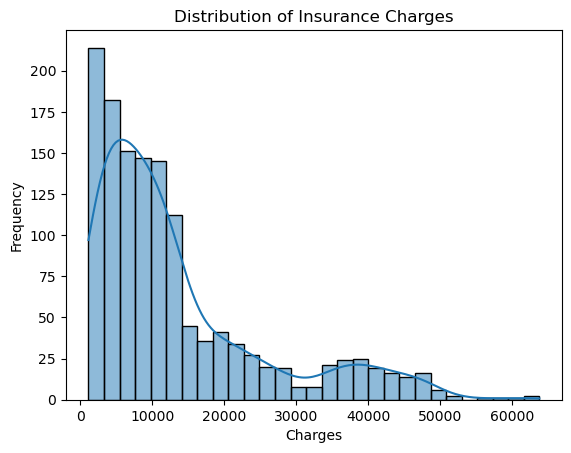

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

### Distribution of Insurance Charges

The distribution of insurance charges is right-skewed.

This means:
- Most individuals have relatively low medical costs
- A small number of individuals have very high charges

This suggests the presence of outliers in the dataset.

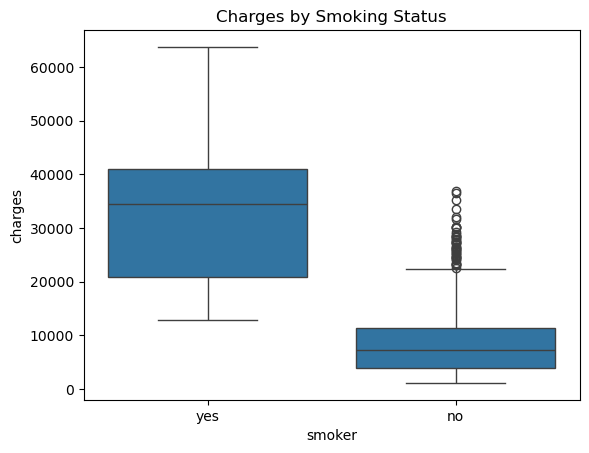

In [17]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

### Charges vs Smoking Status

There is a significant difference in charges between smokers and non-smokers.

Smokers tend to have much higher medical insurance costs compared to non-smokers.

This indicates that smoking is a major factor influencing insurance charges.

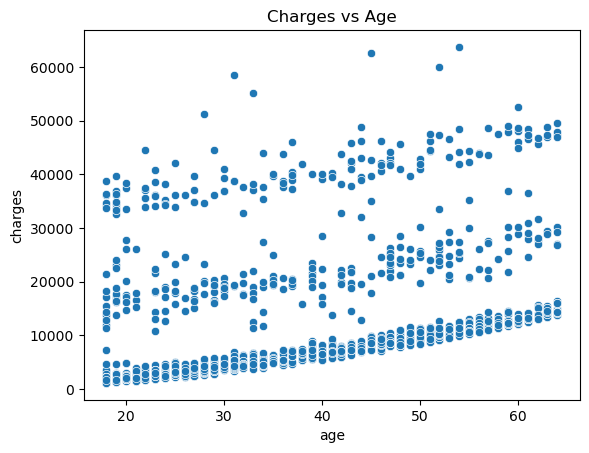

In [18]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Charges vs Age")
plt.show()

### Charges vs Age

There is a positive relationship between age and insurance charges.

As age increases, medical costs tend to increase, likely due to higher health risks.

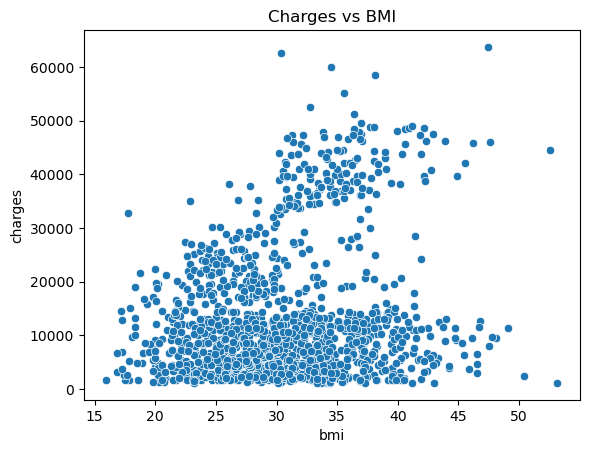

In [19]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("Charges vs BMI")
plt.show()

### Charges vs BMI

BMI shows a moderate positive relationship with insurance charges.

Higher BMI values may be associated with increased health risks, leading to higher insurance costs.

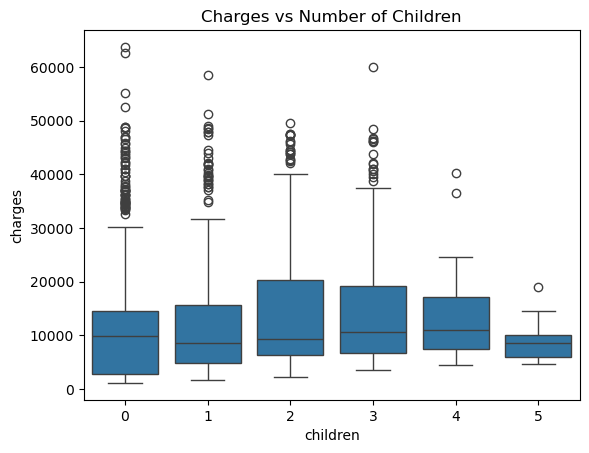

In [20]:
sns.boxplot(x='children', y='charges', data=df)
plt.title("Charges vs Number of Children")
plt.show()

### Charges vs Number of Children

There is no strong relationship between the number of children and insurance charges.

The variation in charges does not significantly change across different numbers of dependents.

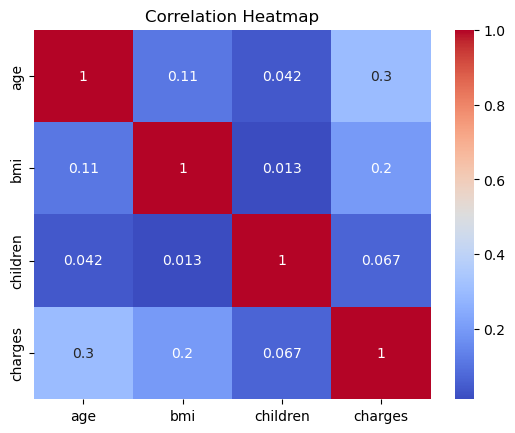

In [21]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

- Age has a positive correlation with charges.
- BMI also shows a moderate positive correlation.
- Number of children has a weak correlation with charges.

Categorical variables like smoking are not included here but were shown earlier to have a strong impact.

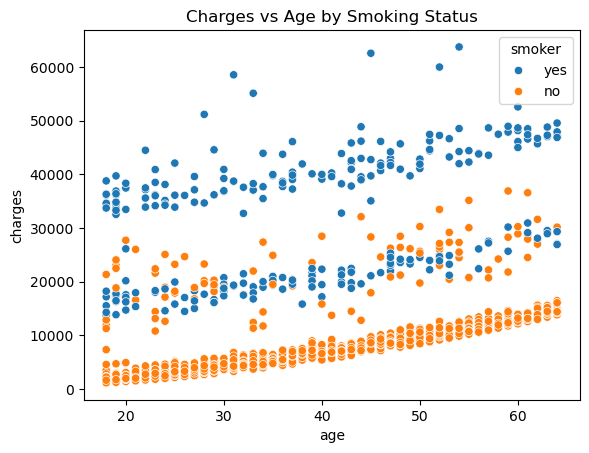

In [22]:
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Charges vs Age by Smoking Status")
plt.show()

This plot shows that smokers consistently have higher charges across all age groups.

It reinforces the conclusion that smoking is the most influential variable.

### Key Insights from EDA

- Smoking status is the most significant factor affecting insurance charges.
- Age and BMI also contribute to higher medical costs.
- Charges are not evenly distributed and contain outliers.
- Number of children has minimal influence on charges.


### Data Preprocessing

Machine learning models cannot work with categorical (text) data.

In this dataset, the following columns are categorical:
- sex
- smoker
- region

These must be converted into numerical values before building a regression model.

We will use **one-hot encoding** to transform these variables.

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [26]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### One-Hot Encoding

One-hot encoding converts categorical variables into binary (0/1) columns.

For example:
- sex > sex_male
- smoker > smoker_yes
- region > multiple region columns

We use `drop_first=True` to avoid the dummy variable trap (multicollinearity), where variables become redundant.

In [28]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   sex_male          1337 non-null   bool   
 5   smoker_yes        1337 non-null   bool   
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 58.8 KB


### Observations After Encoding

- All variables are now numerical.
- The dataset is now suitable for machine learning models.

### Features and Target Variable

In [30]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

### Defining Features and Target Variable

- X (Features): All independent variables used to predict insurance charges
- y (Target): The dependent variable, which is the insurance charges

The goal of the model is to predict the value of charges based on the input features.

### Train-Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Splitting the Dataset

The dataset is split into:
- Training set (80%): used to train the model
- Testing set (20%): used to evaluate model performance

The random_state ensures reproducibility of results.

### Train Linear Regression Model

In [32]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Training the Linear Regression Model

A Linear Regression model is used to learn the relationship between the features and the target variable.

The model finds the best-fitting line that minimizes the prediction error.

In [33]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,age,248.210720
1,bmi,318.701441
2,children,533.009989
3,sex_male,-101.542054
4,smoker_yes,23077.764593
5,region_northwest,-391.761455
6,region_southeast,-838.919616
7,region_southwest,-659.139752


### Model Coefficients

The coefficients show how each feature affects insurance charges.

- Positive coefficient → increases charges
- Negative coefficient → decreases charges

### Predictions

In [34]:
y_pred = model.predict(X_test)

### Making Predictions

The trained Linear Regression model is used to predict insurance charges on the test dataset.

These predictions will be compared with actual values to evaluate model performance.

### Model Performance

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 4177.045561036319
Mean Squared Error (MSE): 35478020.67523559
R2 Score: 0.8069287081198012


### Model Evaluation

- MAE (Mean Absolute Error):
  Measures the average difference between actual and predicted values.

- MSE (Mean Squared Error):
  Penalizes larger errors more than MAE.

- R² Score:
  Indicates how well the model explains the variation in the data.

An R² value closer to 1 means better model performance.

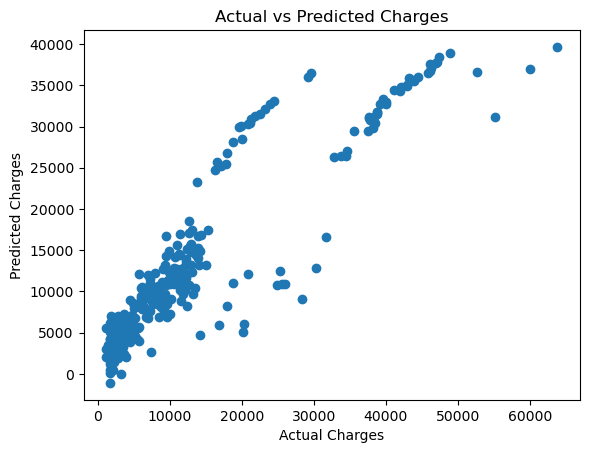

In [36]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

The scatter plot shows how close the predictions are to the actual values.

Points closer to the diagonal line indicate better predictions.

### Reflection

1. Which variables most strongly influence medical insurance charges?

Smoking status has the strongest influence on insurance charges. Age and BMI also significantly affect costs.

---

2. Why might smoking affect insurance costs?

Smoking increases the risk of serious health conditions such as heart disease, lung disease, and cancer. This leads to higher medical expenses, which increases insurance costs.

---

3. What improvements could be made to the model?

- Perform feature scaling
- Handle outliers more effectively
- Add interaction features (e.g., age × smoker)
- Use cross-validation to improve model reliability